<a href="https://colab.research.google.com/github/Anshu-kumar-singh/Loan-approval-Basic-project-/blob/main/LoanApproval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

L

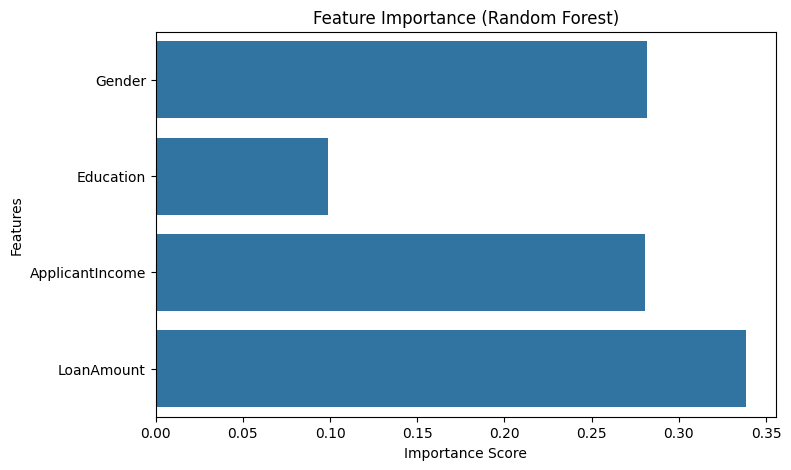

In [1]:
# Loan Approval Prediction using Machine Learning

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

# Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# Display Dataset
print(df.head())

# Rename Columns for Loan Approval Style Project
df = df.rename(columns={
    "Sex": "Gender",
    "Pclass": "Education",
    "Age": "ApplicantIncome",
    "Fare": "LoanAmount",
    "Survived": "Loan_Status"
})

# Select Useful Columns
df = df[[
    "Gender",
    "Education",
    "ApplicantIncome",
    "LoanAmount",
    "Loan_Status"
]]

# Handle Missing Values

# Categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df[["Gender", "Education"]] = cat_imputer.fit_transform(
    df[["Gender", "Education"]]
)

# Numerical columns
num_imputer = SimpleImputer(strategy='median')

df[["ApplicantIncome", "LoanAmount"]] = num_imputer.fit_transform(
    df[["ApplicantIncome", "LoanAmount"]]
)

# Encode Categorical Data
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Education"] = le.fit_transform(df["Education"])

# Features and Target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Models
log_model = LogisticRegression()
tree_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

# Train Models
log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Evaluate Models
for name, model in zip(
    ["Logistic Regression", "Decision Tree", "Random Forest"],
    [log_model, tree_model, rf_model]
):

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"\n{name} Accuracy: {acc:.2f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))

    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    print("-" * 50)

# Hyperparameter Tuning
params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 4, 6]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid=params,
    cv=3
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

# Feature Importance
importance = rf_model.feature_importances_
features = X.columns

# Plot Feature Importance
plt.figure(figsize=(8, 5))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()